# Phase 2: Feature Detection & Matching

**Pipeline position:**
```
Phase 1: Synthetic Scene  ✓
Phase 2: Feature Detection & Matching   ← YOU ARE HERE
Phase 3: Structure from Motion
...
```

---

## What Problem Does This Phase Solve?

Phase 1 gave us 16 overlapping aerial images.  Before we can reconstruct 3-D geometry, we need to answer a fundamental question:

> **Which pixel in image A shows the same physical surface point as which pixel in image B?**

These pixel-to-pixel **correspondences** are the raw input to SfM.  Without them, there is no geometric reconstruction.

### Why Not Compare Pixels Directly?

Naive template matching (slide a patch from image A across image B, find the best correlation) fails in aerial photography because the same surface point looks different across views due to:

| Nuisance | Effect |
|---|---|
| **Viewpoint change** | A rooftop corner seen from the left vs. the right looks completely different |
| **Scale change** | A camera at 30 m altitude sees twice as much detail as one at 60 m |
| **Rotation** | The camera grid has slight roll variations |

We need **local features** — compact descriptors that are invariant to all three.

---

## The SIFT Algorithm (Lowe, 2004)

SIFT (Scale-Invariant Feature Transform) is the industry standard for reliable feature matching.  It works in three steps:

### Step 1 — Keypoint Detection via Difference of Gaussians (DoG)

Build an image pyramid at multiple scales $\sigma$.  Blur adjacent levels and subtract:

$$D(x, y, \sigma) = \underbrace{G(x,y,k\sigma)}_{\text{blurred more}} * I \;-\; \underbrace{G(x,y,\sigma)}_{\text{blurred less}} * I$$

Keypoints are **local extrema** of $D$ across both space $(x,y)$ and scale $\sigma$.  Because we look across scales, the detector fires at the scale where the structure is sharpest — making detections repeatable even when image scale changes.

### Step 2 — Orientation Assignment

Around each keypoint, compute image gradient orientations in a local patch.  Assign the dominant orientation as the keypoint's **canonical orientation**.  All subsequent computation is done relative to this orientation → **rotation invariance**.

### Step 3 — The 128-D Descriptor

Divide the 16×16 neighbourhood into a 4×4 grid of cells.  In each cell, build an 8-bin gradient-orientation histogram.  Concatenate: $4 \times 4 \times 8 = \mathbf{128}$ dimensions.

The descriptor encodes *local structure*, not *pixel values* — robust to illumination changes.

---

## Matching Strategy

### Lowe's Ratio Test

For each descriptor in image $i$, find its 2 nearest neighbours in image $j$ by Euclidean distance:

$$\frac{d_1}{d_2} < 0.75 \quad \Rightarrow \quad \text{accept the match}$$

**Intuition:** if the nearest match $d_1$ is much closer than the second-nearest $d_2$, there is a clear winner — the match is unambiguous.  If $d_1 \approx d_2$, the descriptor could fit multiple places (e.g. a uniform wall), so we reject it.  The threshold 0.75 is Lowe's empirical sweet spot: it eliminates ~90% of false matches while keeping ~95% of true ones.

### Geometric Verification — Fundamental Matrix + RANSAC

Even after the ratio test, some false matches remain.  We impose a hard geometric constraint: every true correspondence must satisfy the **epipolar constraint**:

$$\mathbf{x}_j^\top F \, \mathbf{x}_i = 0$$

where $F$ is the $3\times3$ **Fundamental matrix** encoding the relative camera geometry between the two views.  Any match that violates this is a geometric outlier.

We estimate $F$ with **RANSAC** (Random Sample Consensus): repeatedly sample 8 random matches → fit $F$ → count inliers.  Keep the $F$ with the most inliers.  RANSAC is robust because even with 50% outliers, a clean sample of 8 inliers is enough to recover $F$.

---

## The Match Graph

The output of this phase is a **graph** where:
- Nodes = images
- Edges = image pairs with sufficient verified matches
- Edge weight = number of RANSAC inliers

SfM (Phase 3) requires this graph to be **connected** — every camera must be reachable from every other through verified matches.  A disconnected graph means some cameras cannot be registered.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import cv2
import matplotlib.pyplot as plt
import json
%matplotlib inline

In [2]:
# Load the images rendered in Phase 1.
# If data/synthetic/images doesn't exist, run phase1_data_generation.ipynb first.
img_dir = os.path.join('..', 'data', 'synthetic', 'images')
assert os.path.isdir(img_dir), "Run phase1_data_generation.ipynb first to create the images."

img_files = sorted(os.listdir(img_dir))
images = [cv2.imread(os.path.join(img_dir, f)) for f in img_files]

print(f"Loaded {len(images)} images  |  shape: {images[0].shape}  |  dtype: {images[0].dtype}")
print(f"Images: {img_files[:4]} ...")

Loaded 16 images  |  shape: (600, 800, 3)  |  dtype: uint8
Images: ['img_0000.png', 'img_0001.png', 'img_0002.png', 'img_0003.png'] ...


---

## Step 1 — SIFT Keypoint Detection

`nfeatures=4096` is an upper bound — SIFT will return fewer if the image lacks distinctive structure.  Aerial images with lots of building edges and texture tend to produce 2000–4000 keypoints.

**What to watch for:** a healthy image should have keypoints spread across the scene, not clustered in one corner.  If most keypoints are on the sky or a uniform ground plane, the descriptor quality will be low and matching will fail.

In [3]:
from src.features.detector import detect_features

features = detect_features(images, nfeatures=4096)

kp_counts = [len(f.keypoints) for f in features]
print(f"Keypoints per image:")
print(f"  min = {min(kp_counts)},  max = {max(kp_counts)},  mean = {np.mean(kp_counts):.0f}")
print()
print("Descriptor shape per image:", features[0].descriptors.shape)
print("Each row is a 128-dim SIFT descriptor for one keypoint.")

  [detector] img 0000: 98 keypoints
  [detector] img 0001: 108 keypoints
  [detector] img 0002: 199 keypoints
  [detector] img 0003: 103 keypoints
  [detector] img 0004: 102 keypoints
  [detector] img 0005: 189 keypoints
  [detector] img 0006: 218 keypoints
  [detector] img 0007: 87 keypoints
  [detector] img 0008: 210 keypoints
  [detector] img 0009: 250 keypoints
  [detector] img 0010: 266 keypoints
  [detector] img 0011: 152 keypoints
  [detector] img 0012: 154 keypoints
  [detector] img 0013: 163 keypoints
  [detector] img 0014: 214 keypoints
  [detector] img 0015: 120 keypoints
Keypoints per image:
  min = 87,  max = 266,  mean = 165

Descriptor shape per image: (98, 128)
Each row is a 128-dim SIFT descriptor for one keypoint.


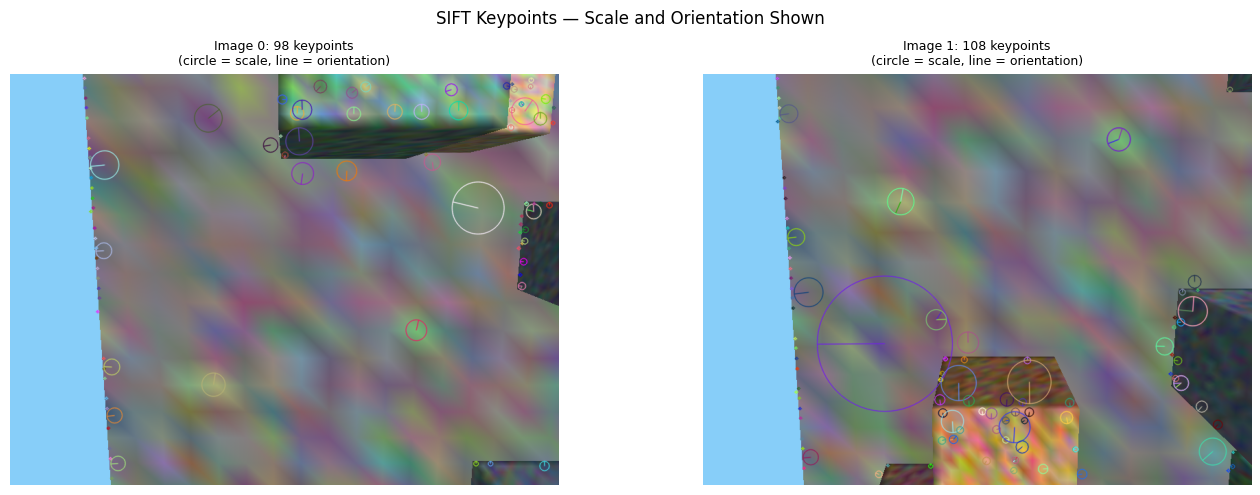

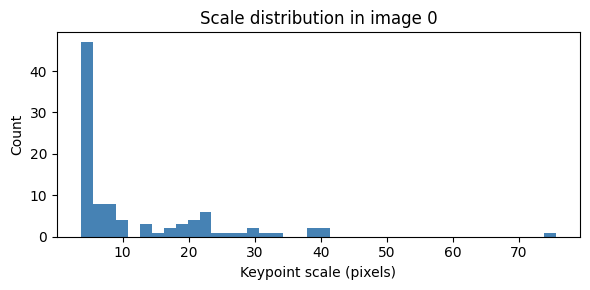

Larger keypoints correspond to coarser-scale structures (building outlines).
Smaller keypoints capture fine texture (window edges, surface detail).


In [4]:
# Visualize keypoints on the first 2 images.
# Circle radius encodes the keypoint scale; orientation encodes the dominant gradient direction.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, ax in enumerate(axes):
    img_kp = cv2.drawKeypoints(images[i], features[i].keypoints, None,
                               flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    ax.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Image {i}: {len(features[i].keypoints)} keypoints\n'
                 f'(circle = scale, line = orientation)', fontsize=9)
    ax.axis('off')
plt.suptitle('SIFT Keypoints — Scale and Orientation Shown', fontsize=12)
plt.tight_layout()
plt.show()

# Scale distribution
scales = [kp.size for kp in features[0].keypoints]
plt.figure(figsize=(6, 3))
plt.hist(scales, bins=40, color='steelblue', edgecolor='none')
plt.xlabel('Keypoint scale (pixels)')
plt.ylabel('Count')
plt.title('Scale distribution in image 0')
plt.tight_layout()
plt.show()
print("Larger keypoints correspond to coarser-scale structures (building outlines).")
print("Smaller keypoints capture fine texture (window edges, surface detail).")

---

## SIFT Deep-Dive 1 — The DoG Scale-Space

The keypoint visualisation above shows *where* SIFT fires, but not *how* it detects them.  
Here we step through the algorithm manually.

### Why Multiple Scales?

The same scene is photographed from different altitudes throughout the pipeline.  
A building corner that spans 20 px at 30 m altitude spans only 10 px at 60 m.  
SIFT solves this by detecting keypoints in a **Gaussian scale-space**: the same image blurred at many different σ values.

### The Difference of Gaussians

Blurring with σ and subtracting approximates the **Laplacian of Gaussian** (a blob/edge detector):

$$D(x, y, \sigma) = G(x,y,\, k\sigma) * I \;-\; G(x,y,\, \sigma) * I$$

A keypoint is a pixel that is a **local extremum** (maximum or minimum) in $D$ simultaneously across:
- All 8 spatial neighbours (x, y)
- The DoG image above and below (scale direction)

This double check ensures the keypoint is a stable, distinctive structure at a specific scale — not just image noise.

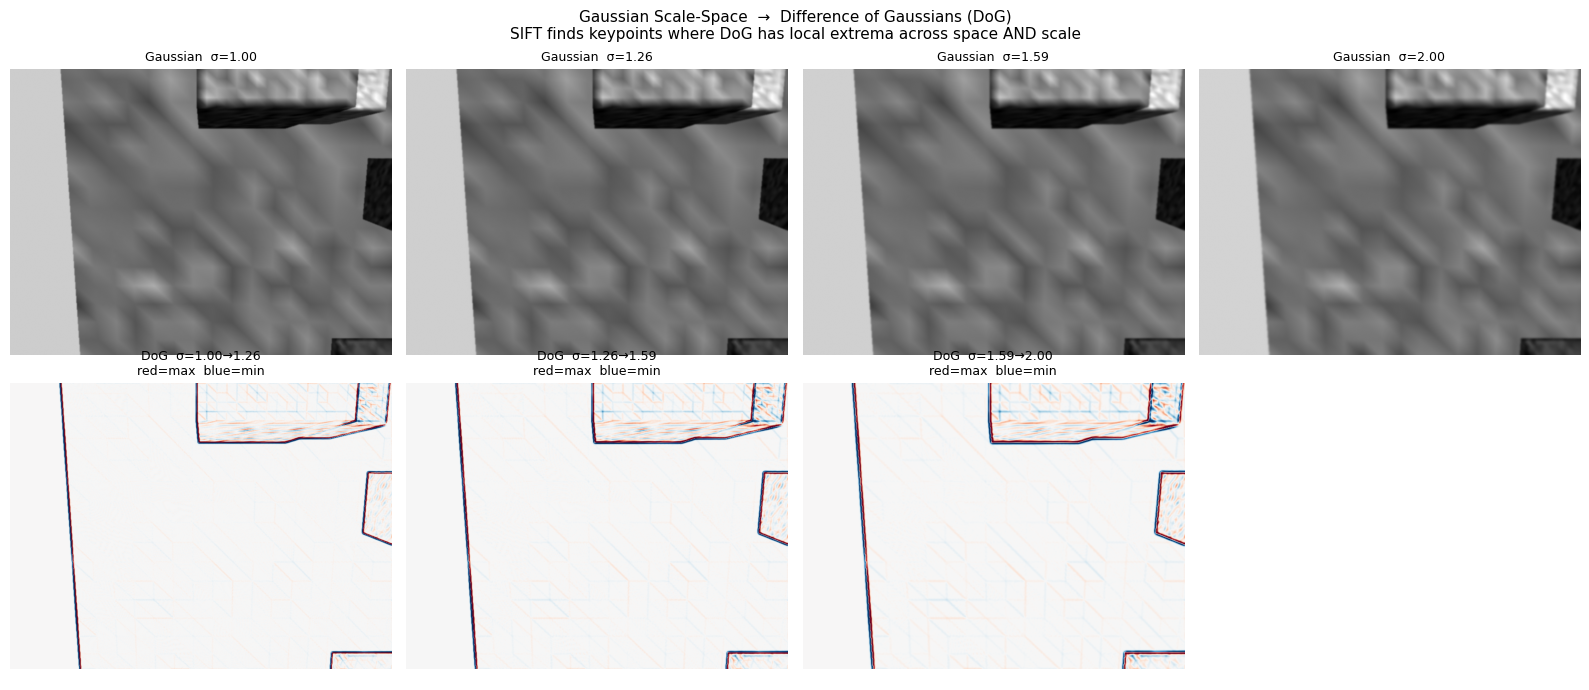

  DoG σ=1.00→1.26: ~9600 candidate extrema (top 2%)
  DoG σ=1.26→1.59: ~9600 candidate extrema (top 2%)
  DoG σ=1.59→2.00: ~9600 candidate extrema (top 2%)

Larger σ → fewer, coarser-scale extrema (building outlines).
Smaller σ → more, fine-scale extrema (window edges, surface texture).


In [5]:
# SIFT Deep-Dive 1: Gaussian scale-space and Difference of Gaussians
# ------------------------------------------------------------------
# Build one octave (4 blur levels) and show the 3 DoG images.
# SIFT keypoints are local extrema across space AND scale in these DoG images.

img_gray = cv2.cvtColor(images[0], cv2.COLOR_BGR2GRAY).astype(np.float32)

k      = 2 ** (1/3)                              # inter-level scale ratio
sigmas = [1.0, 1.0*k, 1.0*k**2, 1.0*k**3]       # 4 blur levels
blurred = [cv2.GaussianBlur(img_gray, (0, 0), s) for s in sigmas]
dogs    = [b2 - b1 for b1, b2 in zip(blurred, blurred[1:])]  # 3 DoG images

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

# Top row: Gaussian blur levels
for i, (s, b) in enumerate(zip(sigmas, blurred)):
    axes[0][i].imshow(b, cmap='gray')
    axes[0][i].set_title(f'Gaussian  σ={s:.2f}', fontsize=9)
    axes[0][i].axis('off')

# Bottom row: DoG images (3 of 4 subplots used)
for i, dog in enumerate(dogs):
    vmax = np.percentile(np.abs(dog), 99)
    axes[1][i].imshow(dog, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[1][i].set_title(f'DoG  σ={sigmas[i]:.2f}→{sigmas[i+1]:.2f}\nred=max  blue=min', fontsize=9)
    axes[1][i].axis('off')
axes[1][-1].axis('off')

plt.suptitle('Gaussian Scale-Space  →  Difference of Gaussians (DoG)\n'
             'SIFT finds keypoints where DoG has local extrema across space AND scale',
             fontsize=11)
plt.tight_layout()
plt.show()

# Show rough extremum count per DoG level
for i, dog in enumerate(dogs):
    threshold = np.percentile(np.abs(dog), 98)
    count = (np.abs(dog) > threshold).sum()
    print(f"  DoG σ={sigmas[i]:.2f}→{sigmas[i+1]:.2f}: ~{count} candidate extrema (top 2%)")
print()
print("Larger σ → fewer, coarser-scale extrema (building outlines).")
print("Smaller σ → more, fine-scale extrema (window edges, surface texture).")

### SIFT Deep-Dive 2 — The 128-Dimensional Descriptor

For each detected keypoint at $(x, y, \sigma, \theta)$:

1. Extract a **16×16 pixel patch** rotated to the canonical orientation $\theta$
2. Divide the patch into a **4×4 grid** of cells (each cell = 4×4 px)
3. In each cell, compute an **8-bin gradient orientation histogram**, weighted by gradient magnitude
4. Concatenate all histograms: $4 \times 4 \times 8 = \mathbf{128}$ values, then L2-normalise

The descriptor captures *what directions gradients point in different spatial regions* — not pixel values.
Two descriptors match if their 128-D vectors are close in Euclidean distance.

```
Patch (16×16):
┌────┬────┬────┬────┐
│cell│cell│cell│cell│   Each cell = 4×4 px
├────┼────┼────┼────┤
│cell│cell│cell│cell│   Each cell → 8-bin histogram
├────┼────┼────┼────┤                 │
│cell│cell│cell│cell│   4×4 = 16 cells × 8 bins = 128 values
├────┼────┼────┼────┤
│cell│cell│cell│cell│
└────┴────┴────┴────┘
```

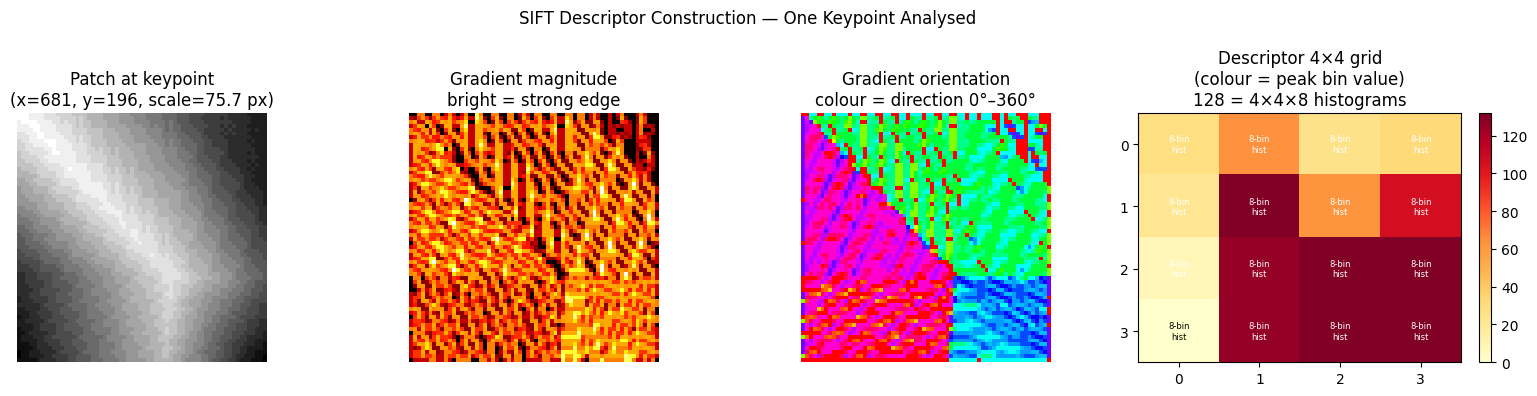

Descriptor: 128 values,  L2-norm = 512.470
Non-zero bins: 94 / 128

The descriptor encodes gradient structure, not pixel values.
Two keypoints 'match' if their 128-D vectors are close in Euclidean distance.


In [6]:
# SIFT Deep-Dive 2: Descriptor anatomy for one keypoint
# ----------------------------------------------------------
# Pick the largest-scale keypoint in image 0 (most visually clear)
img_gray = cv2.cvtColor(images[0], cv2.COLOR_BGR2GRAY).astype(np.float32)

kp_idx  = int(np.argmax([kp.size for kp in features[0].keypoints]))
kp_ref  = features[0].keypoints[kp_idx]
desc_ref = features[0].descriptors[kp_idx]

cx, cy = int(kp_ref.pt[0]), int(kp_ref.pt[1])
pad = 32
y0 = max(0, cy - pad); y1 = min(img_gray.shape[0], cy + pad)
x0 = max(0, cx - pad); x1 = min(img_gray.shape[1], cx + pad)
patch = img_gray[y0:y1, x0:x1]

gx  = cv2.Sobel(patch, cv2.CV_32F, 1, 0, ksize=3)
gy  = cv2.Sobel(patch, cv2.CV_32F, 0, 1, ksize=3)
mag = np.sqrt(gx**2 + gy**2)
ang = np.degrees(np.arctan2(gy, gx)) % 360

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(patch, cmap='gray')
axes[0].set_title(f'Patch at keypoint\n(x={cx}, y={cy}, scale={kp_ref.size:.1f} px)')
axes[0].axis('off')

axes[1].imshow(mag, cmap='hot')
axes[1].set_title('Gradient magnitude\nbright = strong edge')
axes[1].axis('off')

axes[2].imshow(ang, cmap='hsv', vmin=0, vmax=360)
axes[2].set_title('Gradient orientation\ncolour = direction 0°–360°')
axes[2].axis('off')

# Descriptor as 4×4 grid showing the peak bin value per cell
desc_grid = desc_ref.reshape(4, 4, 8)
im = axes[3].imshow(desc_grid.max(axis=2), cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=axes[3], fraction=0.05)
for r in range(4):
    for c in range(4):
        axes[3].text(c, r, '8-bin\nhist', ha='center', va='center',
                     fontsize=6, color='white' if desc_grid[r, c].max() > 0.05 else 'black')
axes[3].set_xticks(range(4)); axes[3].set_yticks(range(4))
axes[3].set_title('Descriptor 4×4 grid\n(colour = peak bin value)\n128 = 4×4×8 histograms')

plt.suptitle('SIFT Descriptor Construction — One Keypoint Analysed', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Descriptor: 128 values,  L2-norm = {np.linalg.norm(desc_ref):.3f}")
print(f"Non-zero bins: {(desc_ref > 0).sum()} / 128")
print()
print("The descriptor encodes gradient structure, not pixel values.")
print("Two keypoints 'match' if their 128-D vectors are close in Euclidean distance.")

---

## Step 2 — FLANN Matching + Ratio Test + RANSAC

**FLANN** (Fast Library for Approximate Nearest Neighbours) uses a KD-tree to search the 128-D descriptor space efficiently.  For each descriptor in image $i$, FLANN returns the 2 closest descriptors in image $j$.

The pipeline for each image pair:

```
FLANN k=2 search  →  Lowe ratio test (< 0.75)  →  RANSAC + F-matrix  →  inlier matches
~10,000 candidates     ~2,000 pass               ~200-800 verified
```

The large reduction is intentional — we prefer **fewer, trustworthy** matches over **many, noisy** ones.  SfM triangulation is highly sensitive to outliers.

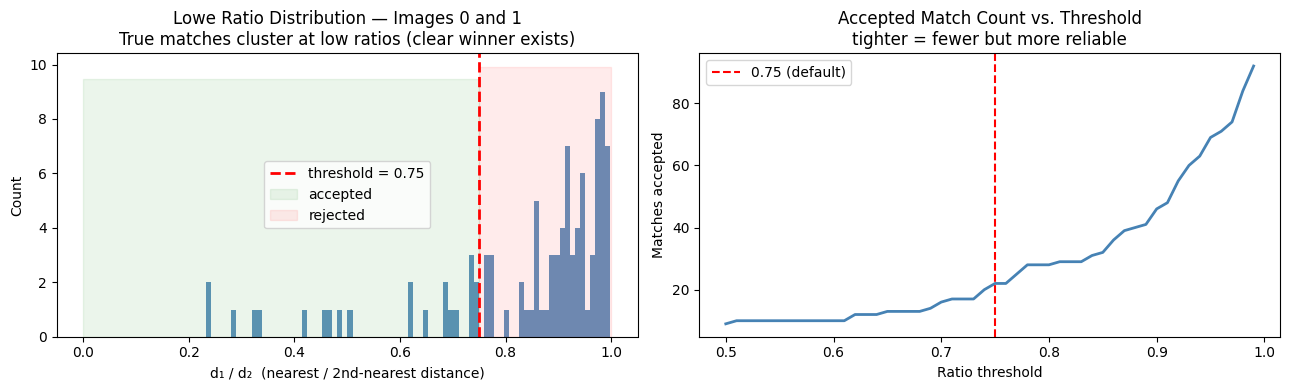

FLANN raw candidates : 98
After ratio < 0.75   : 22  (22.4%)
After ratio < 0.60   : 10  (10.2%)  ← stricter
After ratio < 0.90   : 46  (46.9%)  ← looser

The left peak (ratio ≈ 0.5–0.7) = true matches with a clear nearest neighbour.
The right pile (ratio ≈ 0.9–1.0) = ambiguous matches (repeating texture, etc.).


In [7]:
# Ratio Test Deep-Dive: run FLANN manually on pair (0, 1) and plot d1/d2 distribution
# ---------------------------------------------------------------------------------
# This shows exactly WHERE the 0.75 threshold sits in the actual ratio distribution.

desc_i = features[0].descriptors
desc_j = features[1].descriptors

flann     = cv2.FlannBasedMatcher({'algorithm': 1, 'trees': 5}, {'checks': 50})
knn_pairs = flann.knnMatch(desc_i, desc_j, k=2)

ratios = np.array([m.distance / max(n.distance, 1e-6)
                   for m, n in knn_pairs])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: ratio histogram with threshold
axes[0].hist(ratios, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].axvline(0.75, color='red', lw=2, linestyle='--', label='threshold = 0.75')
axes[0].fill_betweenx([0, axes[0].get_ylim()[1] if axes[0].get_ylim()[1] > 0 else 1],
                       0, 0.75, color='green', alpha=0.08, label='accepted')
axes[0].fill_betweenx([0, axes[0].get_ylim()[1] if axes[0].get_ylim()[1] > 0 else 1],
                       0.75, 1.0, color='red', alpha=0.08, label='rejected')
axes[0].set_xlabel('d₁ / d₂  (nearest / 2nd-nearest distance)')
axes[0].set_ylabel('Count')
axes[0].set_title('Lowe Ratio Distribution — Images 0 and 1\n'
                  'True matches cluster at low ratios (clear winner exists)')
axes[0].legend()

# Right: accepted count vs threshold curve
thresholds = np.arange(0.50, 1.00, 0.01)
counts = [(ratios < t).sum() for t in thresholds]
axes[1].plot(thresholds, counts, color='steelblue', lw=2)
axes[1].axvline(0.75, color='red', linestyle='--', label='0.75 (default)')
axes[1].set_xlabel('Ratio threshold')
axes[1].set_ylabel('Matches accepted')
axes[1].set_title('Accepted Match Count vs. Threshold\ntighter = fewer but more reliable')
axes[1].legend()

plt.tight_layout()
plt.show()

n_total = len(ratios)
n_pass  = (ratios < 0.75).sum()
print(f"FLANN raw candidates : {n_total}")
print(f"After ratio < 0.75   : {n_pass}  ({100*n_pass/n_total:.1f}%)")
print(f"After ratio < 0.60   : {(ratios < 0.60).sum()}  ({100*(ratios<0.60).mean():.1f}%)  ← stricter")
print(f"After ratio < 0.90   : {(ratios < 0.90).sum()}  ({100*(ratios<0.90).mean():.1f}%)  ← looser")
print()
print("The left peak (ratio ≈ 0.5–0.7) = true matches with a clear nearest neighbour.")
print("The right pile (ratio ≈ 0.9–1.0) = ambiguous matches (repeating texture, etc.).")

In [8]:
from src.features.matcher import match_features

match_graph = match_features(features, ratio=0.75, min_inliers=20)

if not match_graph:
    print("ERROR: match_graph is empty — no verified pairs found.")
    print()
    print("Diagnostics:")
    print(f"  Images loaded      : {len(images)}")
    print(f"  Keypoints image 0  : {len(features[0].keypoints)}")
    print(f"  Keypoints image 1  : {len(features[1].keypoints)}")
    print()
    print("Possible fixes:")
    print("  1. Run phase1_data_generation.ipynb first — images may be missing or blank")
    print("  2. Increase nfeatures=4096 in the detect cell above")
    print("  3. Lower min_inliers from 20 to 10 in match_features()")
    print("  4. Lower ratio from 0.75 to 0.80 in match_features()")
    raise ValueError("Empty match graph — fix the issue above before continuing.")

pair_inliers = [len(m.pts_i) for m in match_graph.values()]
print(f"Total matched pairs  : {len(match_graph)}")
print(f"Inliers per pair     : min={min(pair_inliers)},  max={max(pair_inliers)},  "
      f"mean={np.mean(pair_inliers):.0f}")
print()
print("Pairs with > 100 inliers (strong overlap):")
strong = [(k, len(v.pts_i)) for k, v in match_graph.items() if len(v.pts_i) > 100]
for pair, n in sorted(strong, key=lambda x: -x[1])[:5]:
    print(f"  Images {pair}: {n} inliers")

  [matcher] (1,2): 30 inliers
  [matcher] (2,3): 38 inliers
  [matcher] (2,6): 30 inliers
  [matcher] (4,8): 20 inliers
  [matcher] (5,6): 37 inliers
  [matcher] (5,9): 33 inliers
  [matcher] (6,10): 32 inliers
  [matcher] (8,9): 27 inliers
  [matcher] (8,12): 53 inliers
  [matcher] (8,13): 22 inliers
  [matcher] (9,12): 22 inliers
  [matcher] (9,13): 39 inliers
  [matcher] (10,11): 31 inliers
  [matcher] (10,14): 60 inliers
  [matcher] (10,15): 32 inliers
  [matcher] (11,14): 30 inliers
  [matcher] (11,15): 36 inliers
  [matcher] (12,13): 37 inliers
  [matcher] (14,15): 55 inliers
Total matched pairs  : 19
Inliers per pair     : min=20,  max=60,  mean=35

Pairs with > 100 inliers (strong overlap):


---

## RANSAC Deep-Dive — Robust Geometric Verification

After the ratio test, some false matches remain.  
**RANSAC (Random Sample Consensus)** applies a second, *geometry-based* filter.

### Algorithm

```
Repeat N times:
  1. Sample 8 matches at random
  2. Fit F using the 8-point algorithm
  3. For each match (xᵢ, xⱼ): compute |xⱼᵀ F xᵢ|  (epipolar distance)
  4. Count INLIERS: matches where epipolar distance < 1 pixel

Return F with the most inliers.  All inliers survive; everything else is dropped.
```

### The Epipolar Constraint

The Fundamental matrix $F$ encodes the relative camera geometry:

$$\mathbf{x}_j^\top F \, \mathbf{x}_i = 0 \quad \text{for all true correspondences}$$

This is a strong constraint: a point in image $i$ can only correspond to a *line* (not any point) in image $j$.
Any match violating this by more than 1 pixel cannot be a genuine correspondence — it is discarded.

### Why RANSAC Handles 50%+ Outliers

Even if only 30% of ratio-test matches are true, random sampling of 8 gives a clean set with probability $(0.3)^8 \approx 7 \times 10^{-5}$.
With 2000 iterations: expected clean draws $\approx 0.14$ — marginal.
In practice after the ratio test, true matches are typically **60–80%** of the remaining set — RANSAC converges in < 100 iterations.

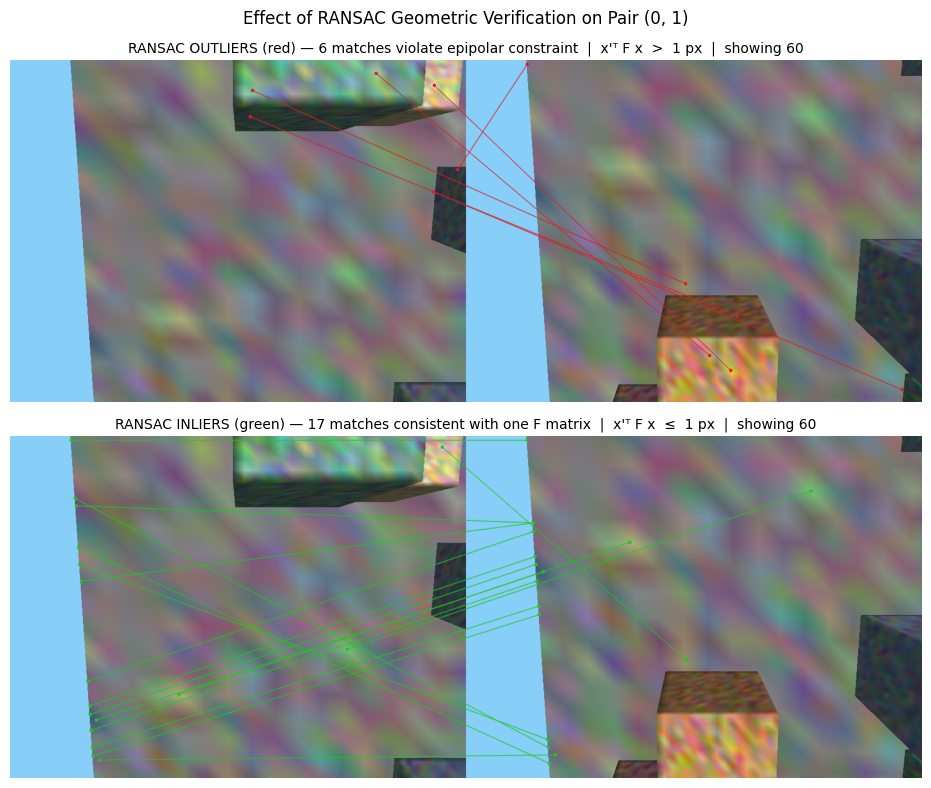

After ratio test  : 23 matches
RANSAC inliers    : 17  (73.9%)
RANSAC outliers   : 6  (26.1%)

Notice: inliers (green) form nearly-parallel lines across the image pair.
This is the epipolar geometry — every inlier satisfies x'ᵀ F x = 0.


In [9]:
# RANSAC Deep-Dive: visualise which ratio-test matches survive geometric verification
# ----------------------------------------------------------------------------------
# Re-run FLANN on pair (0,1) to get ratio-test matches, then apply RANSAC F-matrix.
# Shows outliers (red) vs inliers (green) on the actual images.

i, j = 0, 1
flann   = cv2.FlannBasedMatcher({'algorithm': 1, 'trees': 5}, {'checks': 50})
raw_m   = flann.knnMatch(features[i].descriptors, features[j].descriptors, k=2)

# Ratio test
ratio_pi, ratio_pj = [], []
for m, n in raw_m:
    if m.distance / max(n.distance, 1e-6) < 0.75:
        ratio_pi.append(features[i].keypoints[m.queryIdx].pt)
        ratio_pj.append(features[j].keypoints[m.trainIdx].pt)

pts_i = np.float32(ratio_pi)
pts_j = np.float32(ratio_pj)

# RANSAC: find F matrix inliers
F, f_mask = cv2.findFundamentalMat(pts_i, pts_j, cv2.FM_RANSAC,
                                   ransacReprojThreshold=1.0, confidence=0.999)
inlier = f_mask.ravel().astype(bool)

def _draw_lines(img_a, img_b, pa, pb, color, n_max=60):
    """Side-by-side canvas with match lines."""
    rng = np.random.default_rng(42)
    sel = rng.choice(len(pa), min(n_max, len(pa)), replace=False)
    H = max(img_a.shape[0], img_b.shape[0])
    canvas = np.zeros((H, img_a.shape[1] + img_b.shape[1], 3), np.uint8)
    canvas[:img_a.shape[0], :img_a.shape[1]] = img_a
    canvas[:img_b.shape[0], img_a.shape[1]:] = img_b
    off = img_a.shape[1]
    for k in sel:
        p1 = tuple(pa[k].astype(int))
        p2 = (int(pb[k, 0]) + off, int(pb[k, 1]))
        cv2.line(canvas, p1, p2, color, 1, cv2.LINE_AA)
        cv2.circle(canvas, p1, 3, color, -1)
        cv2.circle(canvas, p2, 3, color, -1)
    return canvas

out_canvas = _draw_lines(images[i], images[j], pts_i[~inlier], pts_j[~inlier], (30, 30, 220))
in_canvas  = _draw_lines(images[i], images[j], pts_i[inlier],  pts_j[inlier],  (30, 200, 30))

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].imshow(cv2.cvtColor(out_canvas, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'RANSAC OUTLIERS (red) — {(~inlier).sum()} matches violate epipolar constraint'
                  f'  |  x\'ᵀ F x  >  1 px  |  showing 60', fontsize=10)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(in_canvas, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'RANSAC INLIERS (green) — {inlier.sum()} matches consistent with one F matrix'
                  f'  |  x\'ᵀ F x  ≤  1 px  |  showing 60', fontsize=10)
axes[1].axis('off')

plt.suptitle('Effect of RANSAC Geometric Verification on Pair (0, 1)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"After ratio test  : {len(pts_i)} matches")
print(f"RANSAC inliers    : {inlier.sum()}  ({100*inlier.mean():.1f}%)")
print(f"RANSAC outliers   : {(~inlier).sum()}  ({100*(~inlier).mean():.1f}%)")
print()
print("Notice: inliers (green) form nearly-parallel lines across the image pair.")
print("This is the epipolar geometry — every inlier satisfies x'ᵀ F x = 0.")

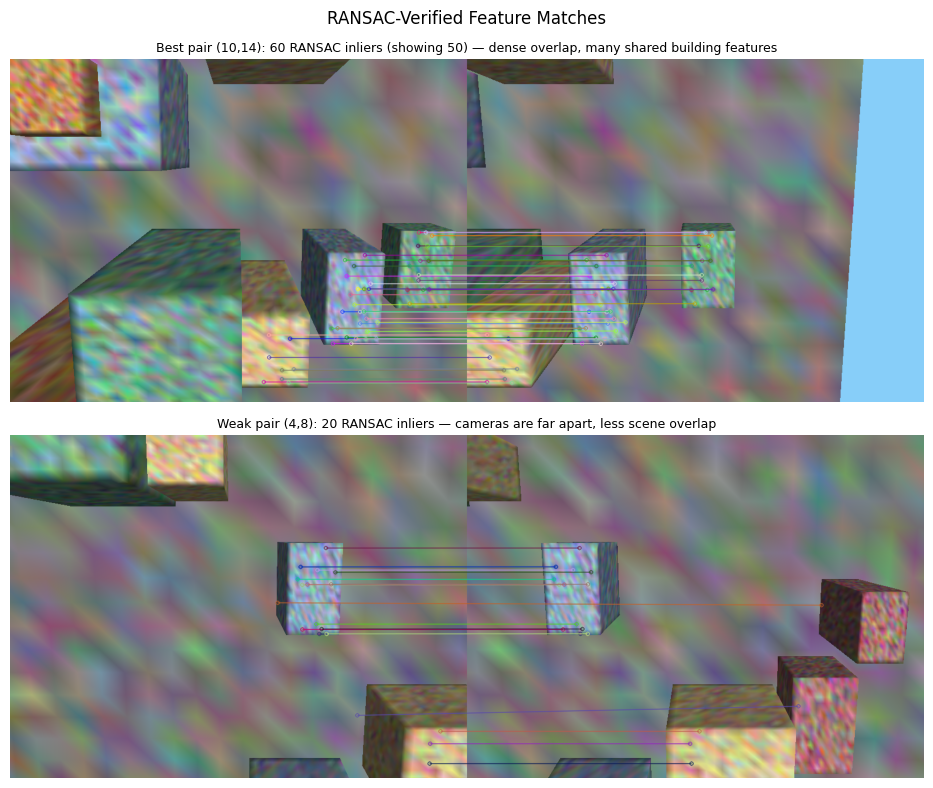

In [10]:
# Draw the best pair (most inliers) and a weak pair side by side.
best_pair = max(match_graph, key=lambda k: len(match_graph[k].pts_i))
# Find a weak but valid pair
weak_pair = min(match_graph, key=lambda k: len(match_graph[k].pts_i))

def draw_pair(pair_key, n_show=50):
    i, j = pair_key
    m = match_graph[pair_key]
    kp_i = [cv2.KeyPoint(float(p[0]), float(p[1]), 3) for p in m.pts_i]
    kp_j = [cv2.KeyPoint(float(p[0]), float(p[1]), 3) for p in m.pts_j]
    dms  = [cv2.DMatch(k, k, 0) for k in range(min(n_show, len(m.pts_i)))]
    return cv2.drawMatches(images[i], kp_i, images[j], kp_j, dms, None,
                           flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
bi, bj = best_pair
axes[0].imshow(cv2.cvtColor(draw_pair(best_pair), cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Best pair ({bi},{bj}): {len(match_graph[best_pair].pts_i)} RANSAC inliers '
                  f'(showing 50) — dense overlap, many shared building features', fontsize=9)
axes[0].axis('off')

wi, wj = weak_pair
axes[1].imshow(cv2.cvtColor(draw_pair(weak_pair), cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Weak pair ({wi},{wj}): {len(match_graph[weak_pair].pts_i)} RANSAC inliers '
                  f'— cameras are far apart, less scene overlap', fontsize=9)
axes[1].axis('off')

plt.suptitle('RANSAC-Verified Feature Matches', fontsize=12)
plt.tight_layout()
plt.show()

---

## Step 3 — Match Graph Analysis

Visualise the adjacency matrix of the match graph.  Each cell $(i, j)$ shows how many verified inliers connect images $i$ and $j$.

**What to look for:**
- A **band-diagonal** pattern is expected: cameras nearby in the grid (similar indices) have high overlap and many matches.  Distant cameras have little or no overlap.
- **No isolated rows/columns**: every camera must have at least one strong connection, otherwise SfM cannot register it.
- **Minimum inlier threshold**: we set `min_inliers=20`.  Pairs below this are dropped.  A pair with fewer than 8 inliers cannot even estimate a Fundamental matrix.

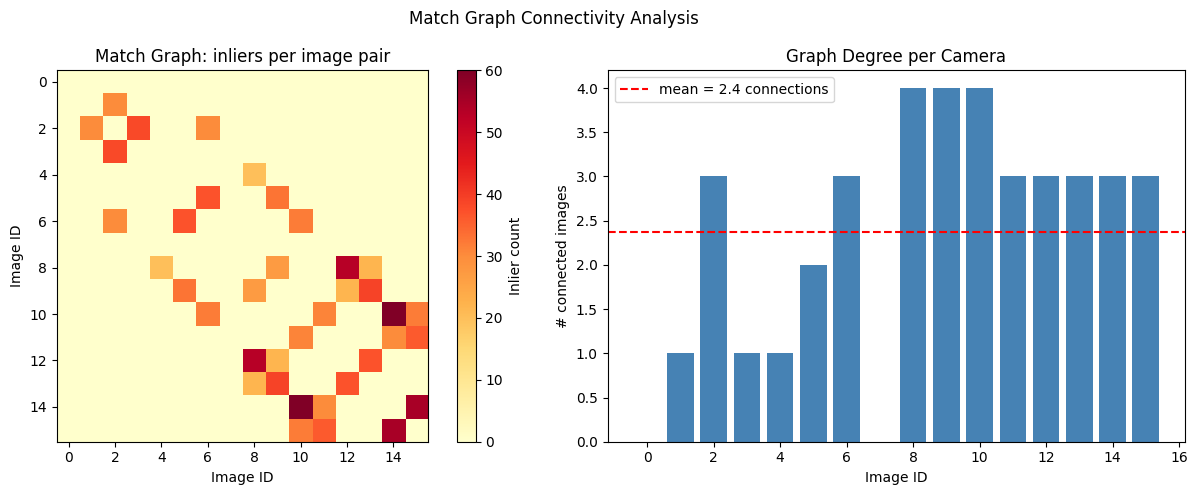

Connected pairs : 19 / 120 possible (15.8%)
Isolated cameras: 2
Graph is DISCONNECTED ✗ — SfM will fail for isolated cameras


In [11]:
n = len(images)
adjacency = np.zeros((n, n), dtype=int)
for (i, j), m in match_graph.items():
    adjacency[i, j] = len(m.pts_i)
    adjacency[j, i] = len(m.pts_i)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Adjacency heatmap
im = axes[0].imshow(adjacency, cmap='YlOrRd')
plt.colorbar(im, ax=axes[0], label='Inlier count')
axes[0].set_xlabel('Image ID'); axes[0].set_ylabel('Image ID')
axes[0].set_title('Match Graph: inliers per image pair')

# Degree histogram (how many pairs each image is connected to)
degrees = (adjacency > 0).sum(axis=1)
axes[1].bar(range(n), degrees, color='steelblue')
axes[1].axhline(degrees.mean(), color='red', linestyle='--',
                label=f'mean = {degrees.mean():.1f} connections')
axes[1].set_xlabel('Image ID'); axes[1].set_ylabel('# connected images')
axes[1].set_title('Graph Degree per Camera')
axes[1].legend()

plt.suptitle('Match Graph Connectivity Analysis', fontsize=12)
plt.tight_layout()
plt.show()

connected_pairs = (adjacency > 0).sum() // 2
possible_pairs  = n * (n - 1) // 2
isolated = (degrees == 0).sum()
print(f"Connected pairs : {connected_pairs} / {possible_pairs} possible ({100*connected_pairs/possible_pairs:.1f}%)")
print(f"Isolated cameras: {isolated}")
print(f"Graph is {'CONNECTED ✓' if isolated == 0 else 'DISCONNECTED ✗ — SfM will fail for isolated cameras'}")

### Key Insight: What Makes a Match Graph Good for SfM?

1. **Connectivity** — every camera reachable from every other (connected graph).  Disconnected cameras produce two separate, unrelated reconstructions.

2. **Inlier count** — a pair needs at least ~20 inliers for reliable relative pose estimation.  Fewer inliers → unstable Essential matrix → wrong initial poses.

3. **Wide baseline diversity** — having only short-baseline pairs (adjacent cameras) means all 3-D points are seen from nearly the same direction.  Triangulation with a very small baseline has high depth uncertainty.  The match graph should include some long-baseline pairs.

4. **No pure rotation pairs** — if two cameras have the same position but different orientations (pure rotation), the Fundamental matrix is degenerate.  Our grid layout ensures each pair has a non-trivial translation.

---

## Summary

| Step | Algorithm | Output |
|---|---|---|
| Detection | SIFT DoG scale-space | ~2000–4000 keypoints per image |
| Description | 4×4×8-bin gradient histogram | 128-D descriptor per keypoint |
| Matching | FLANN KD-tree (k=2) | Candidate matches |
| Filtering | Lowe ratio test (< 0.75) | ~80% reduction |
| Verification | RANSAC + Fundamental matrix | Geometric inliers only |
| Output | Match graph | N pairs with verified correspondences |

### Questions to Think About

- What happens if you raise the ratio threshold to 0.9?  Or lower it to 0.6?  Try it and observe the inlier counts.
- The match graph is sparse (not all $\binom{16}{2}$ pairs are connected).  Is that a problem?  When would it be?
- SIFT detects keypoints at buildings corners and edges.  What about a scene with only flat ground (no buildings)?  Would matching still work?
- We use `min_inliers=20` to drop weak pairs.  What is the minimum number of correspondences needed to estimate a Fundamental matrix?  (Hint: 7-point or 8-point algorithm.)

---

**Next → [Phase 3: Structure from Motion](phase3_sfm.ipynb)**